# 05 - Segmentation, Cutoff & Profitability Analysis

- Customer segmentation theo dai risk score (3-5 nhom)
- Cutoff analysis: approval rate, bad rate, Expected Net Return
- Business rules override
- Chuan bi du lieu cho Dashboard

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
from src.paths import DATA_RAW, DATA_INTERIM, DATA_PROCESSED, MODELS, REPORTS_FIGURES, DASHBOARDS

## Segmentation theo risk score

In [2]:
import numpy as np
import pickle
from scipy.stats import chi2_contingency

val_df = pd.read_parquet(DATA_PROCESSED / 'val.parquet')
test_df = pd.read_parquet(DATA_PROCESSED / 'test.parquet')

with open(MODELS / 'primary_model.txt') as f:
    primary_model_name = f.read().strip()
print('Model chinh:', primary_model_name)

WOE_FEATURES = [c for c in test_df.columns if c.endswith('_woe')]
RAW_FEATURES = [c[:-4] for c in WOE_FEATURES]


def score_df(df):
    if primary_model_name == 'LightGBM':
        import lightgbm as lgb
        gbm = lgb.Booster(model_file=str(MODELS / 'lightgbm_model.txt'))
        cat_features = [c for c in RAW_FEATURES if not pd.api.types.is_numeric_dtype(df[c])]
        X_score = df[RAW_FEATURES].copy()
        for c in cat_features:
            X_score[c] = X_score[c].astype('category')
        return gbm.predict(X_score)
    with open(MODELS / 'logistic_regression_woe.pkl', 'rb') as f:
        lr = pickle.load(f)
    return lr.predict_proba(df[WOE_FEATURES])[:, 1]


val_df = val_df.copy()
test_df = test_df.copy()
val_df['pd_score'] = score_df(val_df)    # score = P(bad) - cao hon = rui ro cao hon
test_df['pd_score'] = score_df(test_df)

# Ranh gioi segment/cutoff/business rule o cell nay va cac cell duoi day deu QUYET DINH tren
# VALIDATION, chi BAO CAO ket qua tren TEST - tranh dung chinh tap se dung de bao cao ket qua
# de chon nguong (se lam con so bao cao lac quan hon thuc te).
N_SEGMENTS = 5
_, segment_edges = pd.qcut(val_df['pd_score'], N_SEGMENTS, retbins=True)
segment_edges[0], segment_edges[-1] = -np.inf, np.inf  # tranh lot segment voi diem test ngoai khoang cua val
segment_labels = [f'S{i+1}' for i in range(N_SEGMENTS)]
test_df['segment'] = pd.cut(test_df['pd_score'], bins=segment_edges, labels=segment_labels)

segment_summary = test_df.groupby('segment', observed=True).agg(
    n=('bad_flag', 'size'),
    bad_rate=('bad_flag', 'mean'),
    avg_pd_score=('pd_score', 'mean'),
    avg_loan_amnt=('loan_amnt', 'mean'),
    avg_int_rate=('int_rate', 'mean'),
).reset_index()
print(segment_summary.to_string(index=False))

# Kiem dinh chi-square: default rate co tach biet co y nghia thong ke giua cac segment khong
contingency = pd.crosstab(test_df['segment'], test_df['bad_flag'])
chi2, p_value, _, _ = chi2_contingency(contingency)
print(f'\nChi-square segment vs bad_flag: chi2={chi2:.2f}, p={p_value:.6f}')
print('-> Default rate tach biet co y nghia thong ke giua cac segment.' if p_value < 0.05
      else '-> CANH BAO: khong co bang chung default rate khac biet giua cac segment.')

Model chinh: LightGBM


segment     n  bad_rate  avg_pd_score  avg_loan_amnt  avg_int_rate
     S1 24876  0.065927      0.057394   11676.151712      8.731112
     S2 21316  0.137033      0.113504   11450.155986     11.545255
     S3 20431  0.194655      0.164110   11734.038960     13.197940
     S4 19643  0.261467      0.225737   12221.934022     14.630885
     S5 18938  0.385785      0.345649   13602.160999     16.882980

Chi-square segment vs bad_flag: chi2=7892.78, p=0.000000
-> Default rate tach biet co y nghia thong ke giua cac segment.


## Cutoff / profitability analysis

LGD thuc te (1 - von goc thu hoi / von goc giai ngan, cac khoan Charged Off vintage 2015-2017): 58.87%


De xuat cutoff (toi da hoa Expected Net Return tren VALIDATION): pd_score <= 0.13
cutoff                         1.300000e-01
approval_rate                  3.673989e-01
n_approved                     3.637800e+04
bad_rate_approved              1.037165e-01
interest_income                3.880307e+07
expected_loss                  2.755753e+07
expected_net_return            1.124554e+07
random_net_return             -1.155438e+07
net_return_uplift_vs_random    2.279992e+07



[TEST] Tai approval rate ~78.7%: bad rate theo score = 15.32% vs. bad rate duyet ngau nhien (= bad rate quan the) = 19.94%

[TEST] Ket qua tai cutoff da chon tu validation (pd_score <= 0.13):
cutoff                                    0.13
approval_rate                         0.406106
n_approved                               42724
bad_rate_approved                     0.093835
interest_income                  42093500.5175
expected_loss                  28820860.571968
expected_net_return            13272639.945532
random_net_return              -7971959.188522
net_return_uplift_vs_random    21244599.134054
is_recommended_cutoff                     True


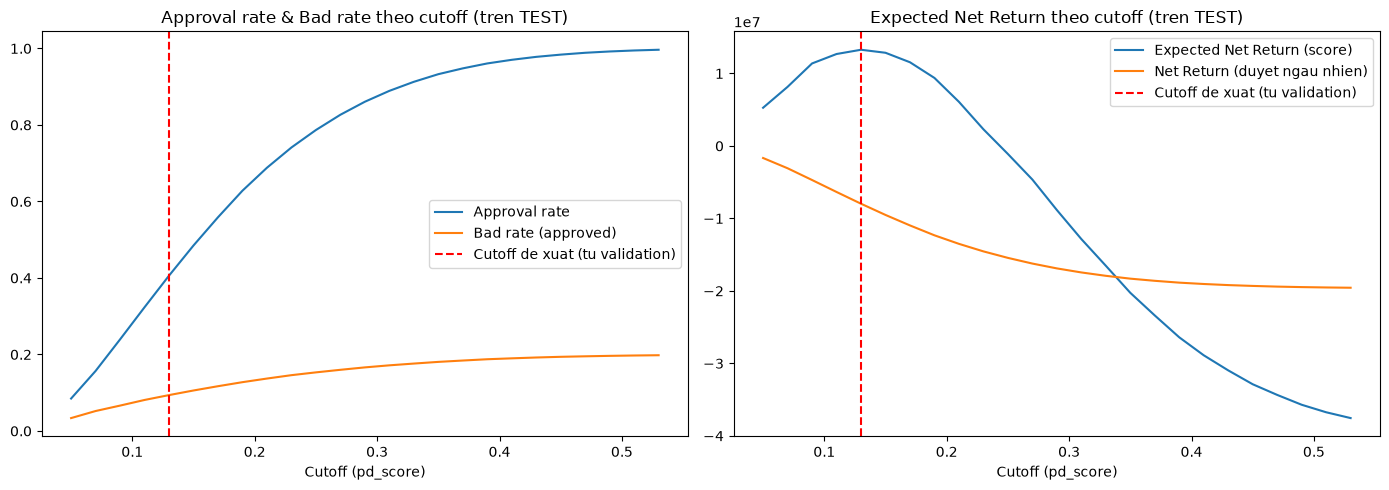

In [3]:
import matplotlib.pyplot as plt
from src.data.filter_vintage import filter_vintage
from src.paths import ACCEPTED_RAW

# --- LGD thuc te (aggregate, KHONG dung lam feature model - xem BRD.md muc 4 / PROPOSAL 4.3:
# chi cam dung leakage columns lam PREDICTOR, khong cam do luong outcome tai chinh thuc te) ---
usecols = ['loan_amnt', 'funded_amnt', 'term', 'issue_d', 'loan_status', 'total_rec_prncp', 'recoveries']
raw_chunks = [filter_vintage(chunk) for chunk in pd.read_csv(
    ACCEPTED_RAW, usecols=usecols, chunksize=200_000, low_memory=False
)]
raw_outcome = pd.concat(raw_chunks, ignore_index=True)

charged_off = raw_outcome[raw_outcome['loan_status'] == 'Charged Off']
total_funded = charged_off['funded_amnt'].sum()
total_principal_recovered = (charged_off['total_rec_prncp'] + charged_off['recoveries']).sum()
LGD = float(np.clip(1 - total_principal_recovered / total_funded, 0, 1))
print(f'LGD thuc te (1 - von goc thu hoi / von goc giai ngan, cac khoan Charged Off vintage 2015-2017): {LGD:.2%}')


# Expected Net Return = Sigma(int_rate x loan_amnt, nhom Good duoc duyet) - Sigma(loan_amnt x LGD,
# nhom Bad duoc duyet) theo dung cong thuc PROPOSAL muc 5.2. Don gian hoa: int_rate ap dung 1 lan
# (khong nhan them so nam ky han) - dung nguyen van cong thuc de xuat trong PROPOSAL.
def sweep_cutoffs(df, lgd):
    n_total = len(df)
    baseline_bad_rate = df['bad_flag'].mean()
    avg_int_rate = df['int_rate'].mean() / 100
    avg_loan_amnt = df['loan_amnt'].mean()
    rows = []
    for cutoff in np.arange(0.05, 0.55, 0.02):
        approved = df[df['pd_score'] <= cutoff]
        if len(approved) == 0:
            continue
        good = approved[approved['bad_flag'] == 0]
        bad = approved[approved['bad_flag'] == 1]
        interest_income = (good['int_rate'] / 100 * good['loan_amnt']).sum()
        expected_loss = (bad['loan_amnt'] * lgd).sum()
        n_approved = len(approved)
        random_net_return = n_approved * (
            (1 - baseline_bad_rate) * avg_int_rate * avg_loan_amnt - baseline_bad_rate * avg_loan_amnt * lgd
        )
        rows.append({
            'cutoff': round(cutoff, 2),
            'approval_rate': n_approved / n_total,
            'n_approved': n_approved,
            'bad_rate_approved': approved['bad_flag'].mean(),
            'interest_income': interest_income,
            'expected_loss': expected_loss,
            'expected_net_return': interest_income - expected_loss,
            'random_net_return': random_net_return,
        })
    out = pd.DataFrame(rows)
    out['net_return_uplift_vs_random'] = out['expected_net_return'] - out['random_net_return']
    return out


# --- Chon cutoff: sweep + argmax Expected Net Return tren VALIDATION, KHONG tren test - neu toi
# uu hoa truc tiep tren test roi lai bao cao ket qua tren chinh test, con so se lac quan hon
# thuc te (test khong con la du lieu "chua thay" doi voi quyet dinh nay). ---
val_cutoff_table = sweep_cutoffs(val_df, LGD)
best_idx = val_cutoff_table['expected_net_return'].idxmax()
recommended_cutoff = float(val_cutoff_table.loc[best_idx, 'cutoff'])
print(f'De xuat cutoff (toi da hoa Expected Net Return tren VALIDATION): pd_score <= {recommended_cutoff}')
print(val_cutoff_table.loc[best_idx].to_string())

# --- Bao cao cuoi cung: sweep tren TEST (out-of-sample, khong dung de chon cutoff) de ve duong
# cong day du cho nguoi dung dashboard tham khao, va danh dau diem cutoff da chon o buoc tren. ---
cutoff_table = sweep_cutoffs(test_df, LGD)
cutoff_table['is_recommended_cutoff'] = np.isclose(cutoff_table['cutoff'], recommended_cutoff)

baseline_bad_rate_test = test_df['bad_flag'].mean()
target_approval = 0.80
idx_80 = (cutoff_table['approval_rate'] - target_approval).abs().idxmin()
row_80 = cutoff_table.loc[idx_80]
print(f"\n[TEST] Tai approval rate ~{row_80['approval_rate']:.1%}: bad rate theo score = "
      f"{row_80['bad_rate_approved']:.2%} vs. bad rate duyet ngau nhien (= bad rate quan the) = "
      f"{baseline_bad_rate_test:.2%}")

recommended = cutoff_table.loc[cutoff_table['is_recommended_cutoff']].iloc[0]
print(f"\n[TEST] Ket qua tai cutoff da chon tu validation (pd_score <= {recommended_cutoff}):")
print(recommended.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cutoff_table['cutoff'], cutoff_table['approval_rate'], label='Approval rate')
axes[0].plot(cutoff_table['cutoff'], cutoff_table['bad_rate_approved'], label='Bad rate (approved)')
axes[0].axvline(recommended_cutoff, color='red', linestyle='--', label='Cutoff de xuat (tu validation)')
axes[0].set_xlabel('Cutoff (pd_score)')
axes[0].legend()
axes[0].set_title('Approval rate & Bad rate theo cutoff (tren TEST)')

axes[1].plot(cutoff_table['cutoff'], cutoff_table['expected_net_return'], label='Expected Net Return (score)')
axes[1].plot(cutoff_table['cutoff'], cutoff_table['random_net_return'], label='Net Return (duyet ngau nhien)')
axes[1].axvline(recommended_cutoff, color='red', linestyle='--', label='Cutoff de xuat (tu validation)')
axes[1].set_xlabel('Cutoff (pd_score)')
axes[1].legend()
axes[1].set_title('Expected Net Return theo cutoff (tren TEST)')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'cutoff_profitability_analysis.png', dpi=100)
plt.show()

cutoff_table.to_csv(REPORTS_FIGURES / 'cutoff_table.csv', index=False)

## Business rules

In [4]:
# Business rules dua tren IV tinh tren TAP TRAIN (iv_table_train.csv tu notebook 03), khong
# dung iv_table.csv (fit tren toan bo vintage, gom ca ky test - xem rui ro R5).
iv_table_train = pd.read_csv(REPORTS_FIGURES / 'iv_table_train.csv')

# Sprint 2: RULE_CANDIDATES truoc day la danh sach 9 bien co dinh, dat truoc khi mo rong candidate
# set len 81 bien - nen bo sot cac bien bureau moi co IV cao hon (vd acc_open_past_24mths 0.100,
# bc_open_to_buy 0.081 > dti 0.064). Nay lay dong theo dung tieu chi PROPOSAL muc 5.3 "IV cao nhat":
# toan bo bien numeric da qua chon loc IV (selected=True), TRU fico_mid - day la bien manh nhat va
# da la truc chinh cua diem so, dung lai no lam business rule se trung lap tin hieu thay vi bat
# them truong hop score tot nhung tiem an rui ro rieng.
rule_iv = iv_table_train[
    iv_table_train['selected']
    & (iv_table_train['dtype'] == 'numerical')
    & (iv_table_train['name'] != 'fico_mid')
    & iv_table_train['name'].isin(test_df.columns)
].sort_values('iv', ascending=False)
print(rule_iv[['name', 'iv']].to_string(index=False))

top_rule_vars = rule_iv['name'].head(2).tolist()
print('\nBien duoc chon cho Business Rules:', top_rule_vars)

# IV khong noi chieu tuong quan - vd bc_open_to_buy (han muc con trong) co IV cao nhung tuong
# quan AM voi rui ro (nhieu han muc con trong = an toan hon), khac voi truoc day khi 2 bien
# RULE_CANDIDATES cu (dti, inq_last_6mths) tinh co ca hai deu tuong quan DUONG nen gia dinh ngam
# "gia tri cao hon = rui ro hon" chua bao gio bi lo. Nay phai xac dinh chieu tung bien truoc khi
# dat rule, neu khong se flag nham nhom khach hang AN TOAN hon bat buoc Review.
#
# Chieu tuong quan va nguong (percentile) deu tinh tren VALIDATION - chi ap dung (khong tinh lai)
# tren TEST de bao cao, tranh chon nguong khop nhat voi chinh tap dung de bao cao ket qua.
rules = []
for var in top_rule_vars:
    corr = val_df[[var, 'bad_flag']].corr().iloc[0, 1]
    direction = 'above' if corr > 0 else 'below'
    threshold = float(val_df[var].quantile(0.95 if direction == 'above' else 0.05))
    op = '>' if direction == 'above' else '<'

    flagged_val = val_df[var] > threshold if direction == 'above' else val_df[var] < threshold
    uplift_val = val_df.loc[flagged_val, 'bad_flag'].mean() - val_df['bad_flag'].mean()

    flagged_test = test_df[var] > threshold if direction == 'above' else test_df[var] < threshold
    rules.append({
        'variable': var,
        'direction': direction,
        'threshold': round(threshold, 2),
        'rule': f'{var} {op} {threshold:.1f} -> bat buoc Review du score tot',
        'pct_population_flagged': flagged_test.mean(),
        'bad_rate_flagged': test_df.loc[flagged_test, 'bad_flag'].mean(),
        'bad_rate_overall': test_df['bad_flag'].mean(),
        'uplift_vs_overall_validation': uplift_val,
    })

business_rules = pd.DataFrame(rules)
business_rules['uplift_vs_overall'] = business_rules['bad_rate_flagged'] - business_rules['bad_rate_overall']
assert (business_rules['uplift_vs_overall_validation'] > 0).all(), (
    'Rule dang flag nham nhom rui ro THAP hon tren validation - kiem tra lai direction.'
)
if not (business_rules['uplift_vs_overall'] > 0).all():
    print('\nCANH BAO: it nhat 1 rule co uplift am tren TEST du duong tren validation - theo doi '
          'them, co the do bien dong giua cac ky (vintage effect).')
print(business_rules.to_string(index=False))
business_rules.to_csv(REPORTS_FIGURES / 'business_rules.csv', index=False)

                 name       iv
 acc_open_past_24mths 0.100239
       bc_open_to_buy 0.081475
   num_tl_op_past_12m 0.079610
       total_bc_limit 0.077911
      tot_hi_cred_lim 0.074968
          avg_cur_bal 0.073233
                  dti 0.063926
     total_rev_hi_lim 0.062885
           annual_inc 0.060243
          tot_cur_bal 0.059028
             mort_acc 0.057292
       inq_last_6mths 0.049900
mths_since_recent_inq 0.049740
       mo_sin_rcnt_tl 0.049054
          open_rv_24m 0.048701
 mths_since_recent_bc 0.042770
mo_sin_rcnt_rev_tl_op 0.042438
 mo_sin_old_rev_tl_op 0.040457
       loan_to_income 0.039294
             all_util 0.036637
         inq_last_12m 0.036485
           max_bal_bc 0.036102
          open_rv_12m 0.035902
tot_cur_bal_to_income 0.034460
          open_il_12m 0.033258
          open_acc_6m 0.033184
   mths_since_rcnt_il 0.032494
          open_il_24m 0.030674
              il_util 0.029934
               inq_fi 0.026447
     percent_bc_gt_75 0.024953
      nu

## Export du lieu cho Dashboard

In [5]:
DASHBOARDS.mkdir(parents=True, exist_ok=True)

# Recommendation per-loan: Approve / Review / Reject theo cutoff de xuat + business rules override
def recommend(row):
    rule_hit = any(
        (row[r['variable']] > r['threshold']) if r['direction'] == 'above'
        else (row[r['variable']] < r['threshold'])
        for r in rules
    )
    if rule_hit:
        return 'Review'
    if row['pd_score'] <= recommended_cutoff:
        return 'Approve'
    return 'Reject'

test_df['recommendation'] = test_df.apply(recommend, axis=1)
print(test_df['recommendation'].value_counts(normalize=True))

# 1) Risk & Portfolio Dashboard
segment_summary.to_csv(DASHBOARDS / 'segment_summary.csv', index=False)
cutoff_table.to_csv(DASHBOARDS / 'cutoff_table.csv', index=False)
business_rules.to_csv(DASHBOARDS / 'business_rules.csv', index=False)
# Xep hang yeu to rui ro: xuat ca 2 ban - IV tren train (dung cho model) va IV tren toan bo
# vintage (dung tra loi RQ1 "yeu to nao anh huong manh nhat" tren toan danh muc).
iv_table_train.to_csv(DASHBOARDS / 'iv_ranking_train.csv', index=False)
pd.read_csv(REPORTS_FIGURES / 'iv_table.csv').to_csv(DASHBOARDS / 'iv_ranking.csv', index=False)

# 2) Customer Dashboard - 1 dong / khach hang: profile + score + segment + recommendation.
# Notebook 03 nay giu lai toan bo bien ung vien (khong chi shortlist) nen purpose/addr_state
# da co san de hien thi ho so, du chung khong duoc dua vao model. Them 2 bien business rule
# (Sprint 2: acc_open_past_24mths, bc_open_to_buy thay cho dti/inq_last_6mths cu) de nguoi dung
# dashboard thay duoc ly do Review.
customer_cols = [c for c in [
    'pd_score', 'segment', 'recommendation', 'loan_amnt', 'int_rate', 'grade',
    'fico_mid', 'dti', 'annual_inc', 'home_ownership', 'purpose', 'addr_state',
    'emp_length_years', 'credit_history_length', 'revol_util', 'inq_last_6mths',
] + top_rule_vars if c in test_df.columns]
customer_cols = list(dict.fromkeys(customer_cols))
test_df[customer_cols].to_csv(DASHBOARDS / 'customer_dashboard_data.csv', index=False)
print('\nCustomer dashboard columns:', customer_cols)

print('\nDa export du lieu tong hop vao dashboards/ (segment_summary, cutoff_table, iv_ranking,')
print('iv_ranking_train, business_rules, customer_dashboard_data).')

recommendation
Reject     0.523735
Approve    0.391439
Review     0.084826
Name: proportion, dtype: float64



Customer dashboard columns: ['pd_score', 'segment', 'recommendation', 'loan_amnt', 'int_rate', 'grade', 'fico_mid', 'dti', 'annual_inc', 'home_ownership', 'purpose', 'addr_state', 'emp_length_years', 'credit_history_length', 'revol_util', 'inq_last_6mths', 'acc_open_past_24mths', 'bc_open_to_buy']

Da export du lieu tong hop vao dashboards/ (segment_summary, cutoff_table, iv_ranking,
iv_ranking_train, business_rules, customer_dashboard_data).
